In [36]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


In [37]:
df=pd.read_csv('Students-Remarks.csv')

In [38]:
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


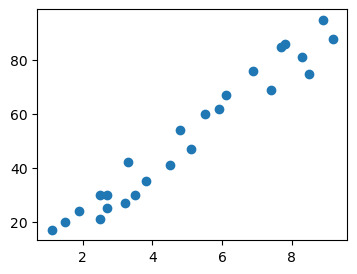

In [39]:
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.scatter(x=df.Hours,y=df.Scores)

In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df.isna().sum()

Hours     0
Scores    0
dtype: int64

In [42]:
X=df[['Hours']]

In [43]:
y=df[['Scores']]

In [44]:
number_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), 
    ("scaler", StandardScaler())
])

catagorical_pipeline = Pipeline([
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("encoder",OneHotEncoder(handle_unknown="ignore",sparse_output=False))
])

In [45]:
transformer = ColumnTransformer([
                            ("num", number_pipeline, make_column_selector(dtype_include=np.number)),
                            ("cat", catagorical_pipeline, make_column_selector(dtype_include=object))
])

In [46]:
model_pipeline = Pipeline([
                            ("preprocessing", transformer),
    ("poly", PolynomialFeatures(degree=3, include_bias=False)),
                            ("model", LinearRegression())
])

In [47]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=36)

In [48]:
model_pipeline.fit(X_train,y_train)

,steps,"[('preprocessing', ...), ('poly', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [49]:
y_prediction_test = model_pipeline.predict(X_test)
r2= r2_score(y_test, y_prediction_test)
RMSE = np.sqrt(mean_squared_error(y_test, y_prediction_test))

print("R2 Score:", r2)
print("RMSE:", RMSE)

R2 Score: 0.4665684275295726
RMSE: 6.999311081505383


In [50]:
hours = float(input("Enter Hours: "))

user_data = pd.DataFrame({
    "Hours": [hours]
})

prediction = model_pipeline.predict(user_data)

print("Predicted Score:", prediction[0])

Enter Hours:  9


Predicted Score: [86.97242885]
